In [1]:
#PyTorch张量：创建、索引、切片、形状变换（view, reshape).
import torch
#创建张量常用方法
#从列表创建
t1=torch.tensor([1,2,3])#从列表或者数组创建张量
t1=torch.zeros(2,3);t1=torch.ones(2,3);t1=torch.eye(3);t1=torch.rand(2,3);t1=torch.randn(2,3)
#全0,全1张量 两行三列。eye是单位矩阵。rand生成随机张量[0,1)均匀分布。
t1=torch.arange(0,10,2) #等差数列0 2 4 6 8
t1=torch.randn(4,5);t1=torch.stack([t1+5,t1,t1+2])#变为三维[3,4,5]
print(f"shape:{t1.shape}")

#索引,切片
x=torch.arange(16).reshape(4,4)
print(f"第一行{x[0]}\n")#x[0,0] x[-1,-1]最后一行最后一列数据
print(f"{x[:2]}\n{x[1:4,2:4]}\n每隔1列取1列\n{x[:,::2]}")#2是步长
indices=[[0,1,2],[1,2,3]]#取指定位置元素{(0,1),(1,2),(2,3)}
print(f"指定位置元素:{x[indices[0],indices[1]]}")
print(x[[0,1,2], [1,2,3]])#方式2
print(x[x>5])

shape:torch.Size([3, 4, 5])
第一行tensor([0, 1, 2, 3])

tensor([[0, 1, 2, 3],
        [4, 5, 6, 7]])
tensor([[ 6,  7],
        [10, 11],
        [14, 15]])
每隔1列取1列
tensor([[ 0,  2],
        [ 4,  6],
        [ 8, 10],
        [12, 14]])
指定位置元素:tensor([ 1,  6, 11])
tensor([ 1,  6, 11])
tensor([ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15])


In [2]:
import torch
x=torch.arange(12)
x_3x4=x.view(3,-1)#-1表示自动推断维度
x_1x12=x.reshape(-1)#变为1维
x=torch.randn(2,3);x1=x.T
print(x.T.shape)
#z=增加/减少维度
x_unsqueeze=x.unsqueeze(0)#在第0维增加1维(1,2,3) 1维(2,1,3)。只加维度
x_squeeze=x_unsqueeze.squeeze(0)#(2,3)
#改变维度顺序
x=torch.randn(2,3,4);x_ord=x.permute(1,0,2)
# x形状(2,3,4)变为x_ord(3,2,4)。
print(f"{x}\n{x_ord}")

torch.Size([3, 2])
tensor([[[ 0.6844,  0.2284, -1.0302,  0.0953],
         [ 0.4981,  1.7989, -0.4002, -0.2349],
         [-1.5201, -1.5738, -0.2709,  0.5163]],

        [[-1.4617, -0.4795, -0.2846,  0.3377],
         [-0.6974,  1.1068,  0.0449, -1.0270],
         [ 0.2832,  0.4515,  0.9431,  1.2203]]])
tensor([[[ 0.6844,  0.2284, -1.0302,  0.0953],
         [-1.4617, -0.4795, -0.2846,  0.3377]],

        [[ 0.4981,  1.7989, -0.4002, -0.2349],
         [-0.6974,  1.1068,  0.0449, -1.0270]],

        [[-1.5201, -1.5738, -0.2709,  0.5163],
         [ 0.2832,  0.4515,  0.9431,  1.2203]]])


In [9]:
import torch
#多变量自动求导
x1=torch.tensor([1.0,2.0,3.0],requires_grad=True)
x2=torch.tensor([4.0,2.0,-2.0],requires_grad=True)
y=x1**2+2*x1*x2+x2**3
y.sum().backward()
print(f"2*x1+2*x2:{x1.grad}")
print(f"2*x2+3*x2^2:{x2.grad}")
#梯度累积
x=torch.tensor(2.0,requires_grad=True)
y1=x**2;y1.backward()
print(x.grad)#4
x.grad.zero_() #用zero后变为12
y2=x**3;y2.backward()
print(x.grad) #4+12=16

2*x1+2*x2:tensor([10.,  8.,  2.])
2*x2+3*x2^2:tensor([50., 16., 18.])
tensor(4.)
tensor(12.)


梯度 (3x^2): tensor([ 3., 12., 27.])


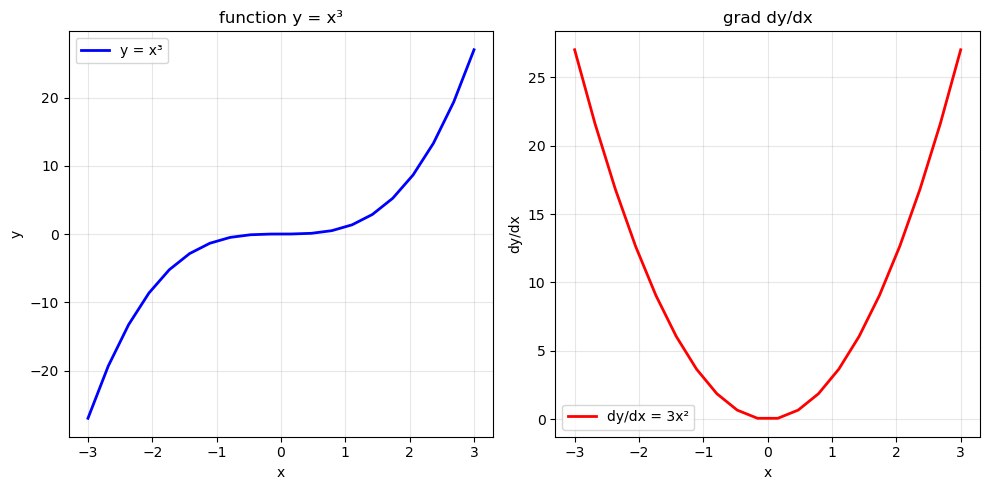

In [2]:
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# 1. 手动验证 y = x^3 的梯度
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x ** 3
y.sum().backward()
print("梯度 (3x^2):", x.grad)   # 应该是 [3, 12, 27]
x.grad.zero_()

# 2. 绘制梯度曲线（不显示，只保存图片）
x_vals = torch.linspace(-3, 3, 20, requires_grad=True)
y_vals = x_vals ** 3
y_vals.sum().backward()
gradients = x_vals.grad.detach().numpy()

plt.figure(figsize=(10, 5))
X_np=x_vals.detach().numpy();y_np=y_vals.detach().numpy()
plt.subplot(1, 2, 1)
plt.plot(X_np,y_np, 'b-', linewidth=2, label='y = x³')
plt.xlabel('x')
plt.ylabel('y')
plt.title('function y = x³')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(X_np, gradients, 'r-', linewidth=2, label="dy/dx = 3x²")
plt.xlabel('x')
plt.ylabel('dy/dx')
plt.title('grad dy/dx')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

tensor([ 3., 12., 27.])


NameError: name 'x_np' is not defined

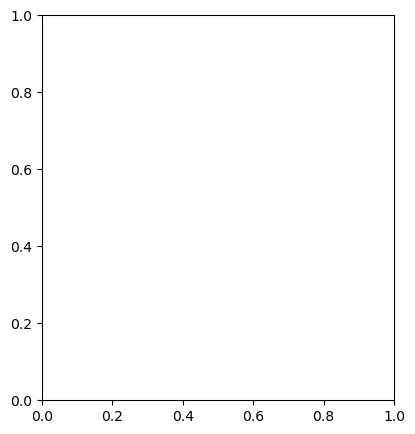